# Pathway coverage after GO:BP-prior retraining

CLAMPfull is retrained with the pinned GO:BP prior and evaluated against canonical non-Reactome pathways and CellMarker with `clusterProfiler::enricher`, independently per database. Recovery uses BH-adjusted p-values within each latent variable (per-LV FDR 0.05); a pathway counts as recovered if it is significant in any LV.

In [2]:
suppressPackageStartupMessages({
    library(data.table)
    library(ggplot2)
})

coverage <- fread(snakemake@input[["coverage_long"]])
panel <- fread(snakemake@input[["panel_ready"]])
stopifnot(nrow(coverage) > 0, nrow(panel) > 0)
coverage <- coverage[database != "reactome"]

FDR <- unique(coverage$fdr)
stopifnot(length(FDR) == 1L)

model_colors <- unlist(snakemake@config[["archs4"]][["coverage"]][["colors"]][["model"]])
dataset_colors <- unlist(snakemake@config[["archs4"]][["coverage"]][["colors"]][["dataset"]])
coverage[, model := factor(model, levels = c("CLAMPfull", "CLAMPbase"))]
cross <- coverage[fraction == 100 & ((model == "CLAMPfull" & seed == 1L) | (model == "CLAMPbase" & ((dataset == "archs4" & seed == 1L) | (dataset != "archs4" & seed == 0L))))]

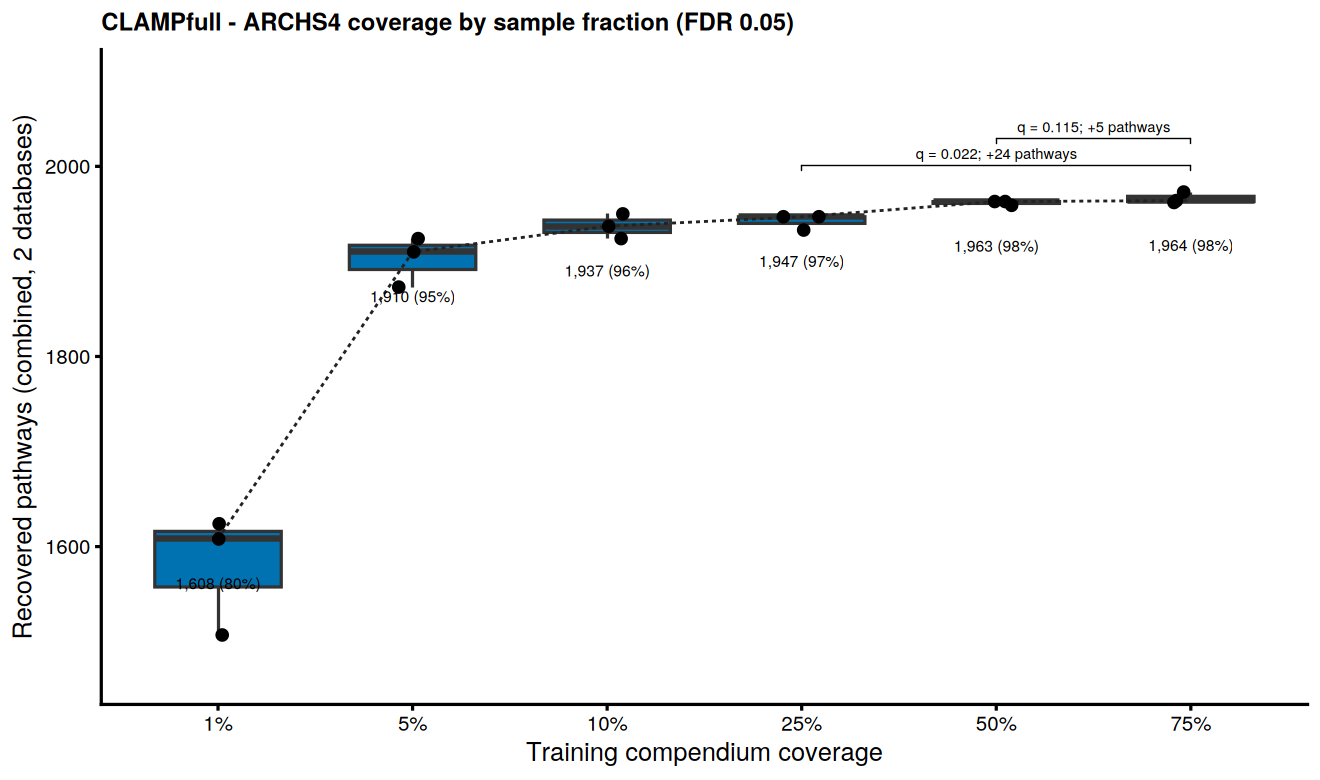

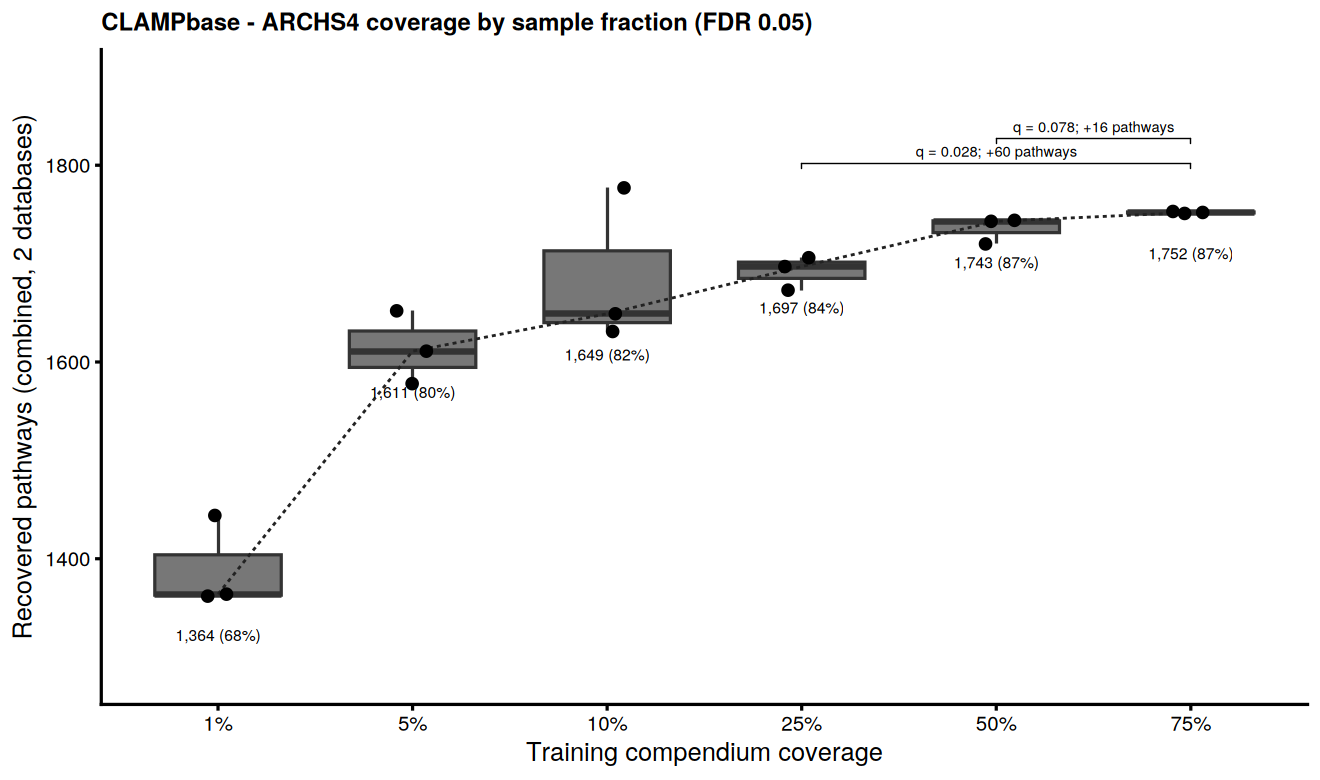

In [3]:
arch_sum <- coverage[dataset == "archs4" & fraction < 100, .(
    recovered_pathways = sum(recovered_pathways),
    eligible_pathways = sum(eligible_pathways),
    n_samples = as.integer(median(n_samples))
), by = .(fraction, seed, model)]
arch_sum[, fraction_label := factor(fraction, levels = sort(unique(fraction)),
    labels = sprintf("%s%%", sort(unique(fraction))))]
fraction_totals <- arch_sum[, .(
    recovered_pathways = as.integer(round(median(recovered_pathways))),
    eligible_pathways = as.integer(round(median(eligible_pathways)))
), by = .(fraction, model)]
fraction_totals[, fraction_label := factor(sprintf("%s%%", fraction), levels = levels(arch_sum$fraction_label))]
fraction_totals[, label := sprintf("%s (%.0f%%)", format(recovered_pathways, big.mark = ",", trim = TRUE), 100 * recovered_pathways / eligible_pathways)]

make_arch_plot <- function(model_name) {
    d <- arch_sum[model == model_name]
    totals <- fraction_totals[model == model_name]
    stopifnot(all(d[, .N, by = fraction]$N == 3L))
    setorder(d, fraction, seed)
    comparison_data <- d[fraction %in% c(10L, 25L, 50L, 75L)]
    comparisons <- rbindlist(lapply(c(25L, 50L), function(fraction_value) {
        reference <- d[fraction == 75L][order(seed)]$recovered_pathways
        candidate <- d[fraction == fraction_value][order(seed)]$recovered_pathways
        data.table(
            group1 = sprintf("%s%%", fraction_value), group2 = "75%",
            p = t.test(reference, candidate, paired = TRUE, alternative = "greater")$p.value,
            difference = as.integer(round(mean(reference - candidate)))
        )
    }))
    comparisons[, p.adj := p.adjust(p, method = "BH")]
    comparisons[, y.position := max(d$recovered_pathways) + seq_len(.N) * diff(range(d$recovered_pathways)) * 0.06]
    comparisons[, label := sprintf("q = %.3f; %+d pathways", p.adj, difference)]
    totals[, label_y := recovered_pathways - 0.10 * diff(range(d$recovered_pathways))]
    ggplot(d, aes(fraction_label, recovered_pathways)) +
        geom_boxplot(fill = model_colors[[model_name]], width = 0.65, outlier.shape = NA) +
        stat_summary(aes(group = 1), fun = median, geom = "line", linetype = "dashed", colour = "#222222", linewidth = 0.6) +
        geom_jitter(width = 0.1, height = 0, size = 2.5) +
        geom_text(data = totals, aes(fraction_label, label_y, label = label), inherit.aes = FALSE, size = 3.2) +
        ggpubr::stat_pvalue_manual(comparisons, label = "label", tip.length = 0.01, size = 3) +
        scale_y_continuous(expand = expansion(mult = c(0.14, 0.18))) +
        labs(
            x = "Training compendium coverage",
            y = "Recovered pathways (combined, 2 databases)",
            title = sprintf("%s - ARCHS4 coverage by sample fraction (FDR %.2f)", model_name, FDR)
        ) +
        theme_classic(base_size = 15) +
        theme(plot.title = element_text(face = "bold", size = 14))
}

options(repr.plot.width = 11, repr.plot.height = 6.5)
make_arch_plot("CLAMPfull")
make_arch_plot("CLAMPbase")

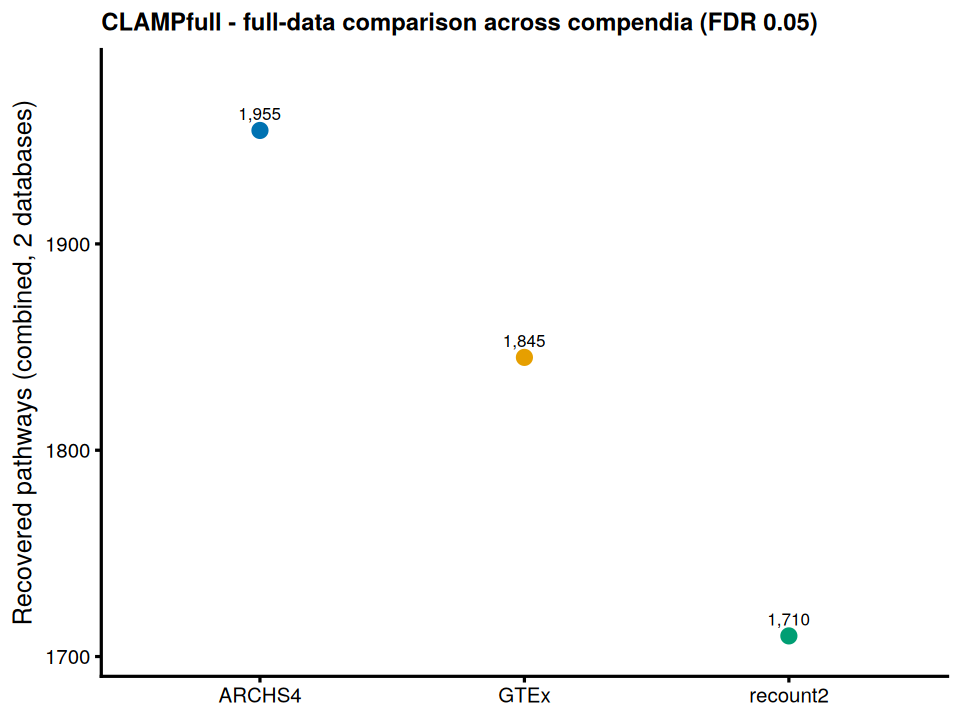

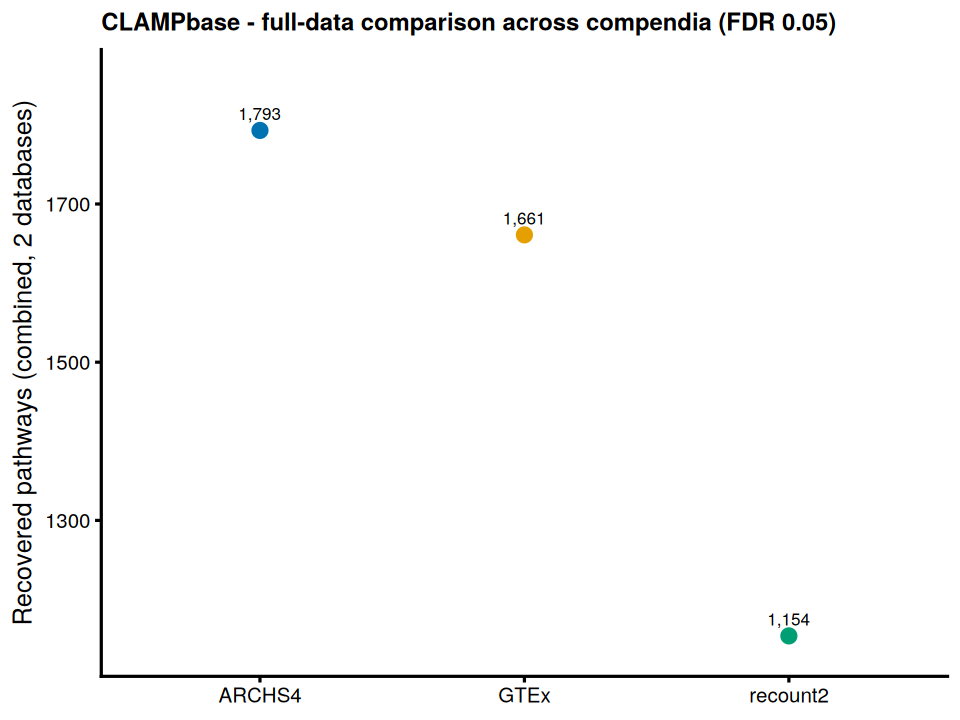

In [4]:
dataset_names <- c(archs4 = "ARCHS4", gtex = "GTEx", recount2 = "recount2")
cross_sum <- cross[, .(recovered_pathways = sum(recovered_pathways)), by = .(dataset, model)]
cross_sum[, label := format(recovered_pathways, big.mark = ",", trim = TRUE)]

make_cross_plot <- function(model_name) {
    d <- cross_sum[model == model_name]
    d[, dataset_label := factor(dataset, levels = names(dataset_names), labels = dataset_names)]
    ggplot(d, aes(dataset_label, recovered_pathways, colour = dataset_label)) +
        geom_point(size = 3.5) +
        geom_text(aes(label = label), vjust = -0.8, colour = "black", size = 3.5) +
        scale_colour_manual(values = dataset_colors, guide = "none") +
        scale_y_continuous(expand = expansion(mult = c(0.08, 0.16))) +
        labs(
            x = NULL,
            y = "Recovered pathways (combined, 2 databases)",
            title = sprintf("%s - full-data comparison across compendia (FDR %.2f)", model_name, FDR)
        ) +
        theme_classic(base_size = 15) +
        theme(plot.title = element_text(face = "bold", size = 14))
}

options(repr.plot.width = 8, repr.plot.height = 6)
make_cross_plot("CLAMPfull")
make_cross_plot("CLAMPbase")

In [5]:
cross[dataset %in% c("gtex", "recount2"), .(
    recovered_pathways, eligible_pathways = unique(eligible_pathways), pct = round(recovered_percent, 1)
), by = .(dataset, database_label, model)][order(dataset, model, database_label)]

dataset,database_label,model,recovered_pathways,eligible_pathways,pct
<chr>,<chr>,<fct>,<int>,<int>,<dbl>
gtex,Canonical non-Reactome,CLAMPfull,1567,1735,90.3
gtex,CellMarker,CLAMPfull,278,289,96.2
gtex,Canonical non-Reactome,CLAMPbase,1383,1735,79.7
gtex,CellMarker,CLAMPbase,278,289,96.2
recount2,Canonical non-Reactome,CLAMPfull,1499,1513,99.1
recount2,CellMarker,CLAMPfull,211,216,97.7
recount2,Canonical non-Reactome,CLAMPbase,948,1513,62.7
recount2,CellMarker,CLAMPbase,206,216,95.4
